# 03 — Monte Carlo Playoff Probability Simulation

Simulate the remainder of the 2024-25 NBA season 10,000 times from a **Feb 1, 2025 midpoint** using Elo-derived win probabilities. Compare simulated playoff odds against what actually happened to validate the simulator.

**What this notebook shows:**
1. Full simulation results table (30 teams × probabilities)
2. Simulated vs actual wins scatter plot (R², MAE)
3. Playoff probability strip chart colored by actual outcome
4. Win distributions for bubble teams (the interesting zone)
5. Detailed miss analysis (which teams did the simulator get wrong and why)
6. Conference standings comparison (sim error bars vs actual)

## Setup

In [1]:
import sys
from pathlib import Path
from datetime import date

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from nba_api.stats.static import teams as nba_static_teams

from db import engine
from src.features.matchup import load_team_games, to_matchup
from src.features.elo import add_elo, final_elos
from src.models.monte_carlo import (
    run_simulation, season_state_at, simulate_once,
    seed_teams, conference_of, win_probability,
)

sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

TEAM_LOOKUP = {t['id']: t for t in nba_static_teams.get_teams()}
def abbrev(tid): return TEAM_LOOKUP.get(int(tid), {}).get('abbreviation', str(tid))
def full_name(tid): return TEAM_LOOKUP.get(int(tid), {}).get('full_name', str(tid))

CUTOFF = date(2025, 2, 1)
SEASON = '2024-25'
N_SIMS = 10_000

print(f"Cutoff date: {CUTOFF}")
print(f"Season: {SEASON}")
print(f"Simulations: {N_SIMS:,}")

Cutoff date: 2025-02-01
Season: 2024-25
Simulations: 10,000


## 1. Run Simulation + Load Actual Results

In [2]:
sim = run_simulation(CUTOFF, n_simulations=N_SIMS, season=SEASON, seed=42)

# Actual final standings
raw = load_team_games(engine)
actual_season = raw[(raw['season'] == SEASON) & (raw['season_type'] == 'Regular Season')]
actual_standings = actual_season.groupby('team_id').agg(
    actual_wins=('wl', lambda s: (s == 'W').sum()),
    actual_losses=('wl', lambda s: (s == 'L').sum()),
).reset_index()
actual_standings['conference'] = actual_standings['team_id'].map(conference_of)
actual_standings['team'] = actual_standings['team_id'].apply(abbrev)

# Assign actual seeds
actual_seeded = []
for conf in ('East', 'West'):
    c = actual_standings[actual_standings['conference'] == conf].sort_values(
        'actual_wins', ascending=False).reset_index(drop=True)
    c['actual_seed'] = range(1, len(c) + 1)
    c['actual_status'] = c['actual_seed'].map(
        lambda s: 'PLAYOFF' if s <= 6 else 'PLAY-IN' if s <= 10 else 'LOTTERY')
    actual_seeded.append(c)
actual_final = pd.concat(actual_seeded, ignore_index=True)

# Merge
compare = sim.merge(actual_final[['team_id', 'actual_wins', 'actual_losses',
                                   'actual_seed', 'actual_status']], on='team_id')
compare['sim_status'] = np.where(
    compare['playoff_prob'] >= 0.5, 'PLAYOFF',
    np.where(compare['playoff_prob'] + compare['playin_prob'] >= 0.5, 'PLAY-IN', 'LOTTERY'))
compare['correct'] = compare['sim_status'] == compare['actual_status']
compare['made_playoffs'] = (compare['actual_status'] == 'PLAYOFF').astype(int)

acc = compare['correct'].mean()
print(f"Playoff/play-in/lottery classification accuracy: {acc:.1%} ({compare['correct'].sum()}/30)")
print(f"Games played per team at cutoff: ~{compare['current_wins'].mean() + compare['current_losses'].mean():.0f}")
print(f"Games remaining to simulate: ~{82 - compare['current_wins'].mean() - compare['current_losses'].mean():.0f}")

2026-04-17 01:14:41,647 [INFO] As of 2025-02-01 (2024-25): 30 teams, 720 played, 510 remaining


Playoff/play-in/lottery classification accuracy: 80.0% (24/30)
Games played per team at cutoff: ~48
Games remaining to simulate: ~34


## 2. Full Results Table

Every team's simulated playoff probability alongside what actually happened. Color-coded by whether the simulation called it correctly.

In [3]:
display_cols = ['team', 'conference', 'current_wins', 'current_losses',
                'wins_mean', 'wins_p5', 'wins_p95', 'actual_wins',
                'playoff_prob', 'playin_prob', 'lottery_prob',
                'sim_status', 'actual_status', 'correct']

styled = (
    compare.sort_values(['conference', 'actual_seed'])[display_cols]
    .style
    .format({'playoff_prob': '{:.1%}', 'playin_prob': '{:.1%}', 'lottery_prob': '{:.1%}',
             'wins_mean': '{:.1f}'})
    .apply(lambda row: ['background-color: #d4edda' if row['correct'] else
                        'background-color: #f8d7da'] * len(row), axis=1)
)
styled

,team,conference,current_wins,current_losses,wins_mean,wins_p5,wins_p95,actual_wins,playoff_prob,playin_prob,lottery_prob,sim_status,actual_status,correct
0,CLE,East,39,9,62.9,59,67,64,100.0%,0.0%,0.0%,PLAYOFF,PLAYOFF,True
1,BOS,East,34,15,56.1,52,60,61,100.0%,0.0%,0.0%,PLAYOFF,PLAYOFF,True
2,NYK,East,32,17,51.3,47,56,51,99.9%,0.1%,0.0%,PLAYOFF,PLAYOFF,True
3,IND,East,27,20,49.0,45,53,50,99.4%,0.6%,0.0%,PLAYOFF,PLAYOFF,True
4,MIL,East,26,20,44.4,40,49,48,83.4%,16.5%,0.1%,PLAYOFF,PLAYOFF,True
6,DET,East,24,24,40.2,36,45,44,26.2%,70.9%,2.9%,PLAY-IN,PLAYOFF,False
7,ORL,East,24,26,39.2,35,43,41,14.4%,80.9%,4.7%,PLAY-IN,PLAY-IN,True
8,ATL,East,22,27,38.0,34,42,40,8.5%,80.4%,11.2%,PLAY-IN,PLAY-IN,True
10,CHI,East,21,28,34.7,30,39,39,0.5%,43.7%,55.8%,LOTTERY,PLAY-IN,False
5,MIA,East,24,23,42.7,38,47,37,64.6%,34.9%,0.5%,PLAYOFF,PLAY-IN,False


## 3. Simulated vs Actual Wins — Scatter Plot

Each dot is a team. Tight clustering around the diagonal means the Elo-based simulation captures team strength well at the midpoint.

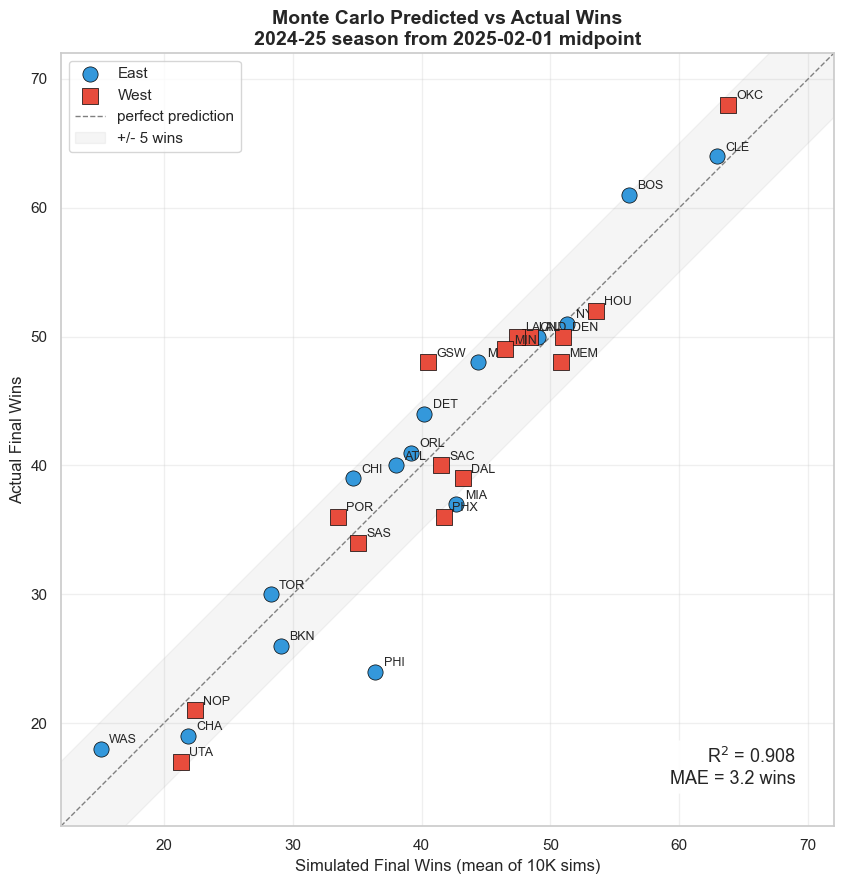

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))

for conf, marker, color in [('East', 'o', '#3498db'), ('West', 's', '#e74c3c')]:
    c = compare[compare['conference'] == conf]
    ax.scatter(c['wins_mean'], c['actual_wins'], s=120, marker=marker,
               c=color, edgecolor='black', lw=0.5, label=conf, zorder=3)
    for _, row in c.iterrows():
        ax.annotate(row['team'], (row['wins_mean'], row['actual_wins']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.plot([12, 72], [12, 72], ls='--', color='gray', lw=1, label='perfect prediction')
ax.fill_between([12, 72], [7, 67], [17, 77], alpha=0.08, color='gray', label='+/- 5 wins')
ax.set_xlabel('Simulated Final Wins (mean of 10K sims)', fontsize=12)
ax.set_ylabel('Actual Final Wins', fontsize=12)
ax.set_title(f'Monte Carlo Predicted vs Actual Wins\n2024-25 season from {CUTOFF} midpoint',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(12, 72); ax.set_ylim(12, 72)
ax.set_aspect('equal')
ax.grid(alpha=0.3)

r2 = r2_score(compare['actual_wins'], compare['wins_mean'])
mae = (compare['actual_wins'] - compare['wins_mean']).abs().mean()
ax.text(0.95, 0.05, f'R$^2$ = {r2:.3f}\nMAE = {mae:.1f} wins',
        transform=ax.transAxes, fontsize=13, verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.tight_layout()

## 4. Playoff Probability vs Actual Outcome

Each team plotted by its simulated playoff probability, colored by what actually happened. Green dots should cluster right, red dots left, and orange in between.

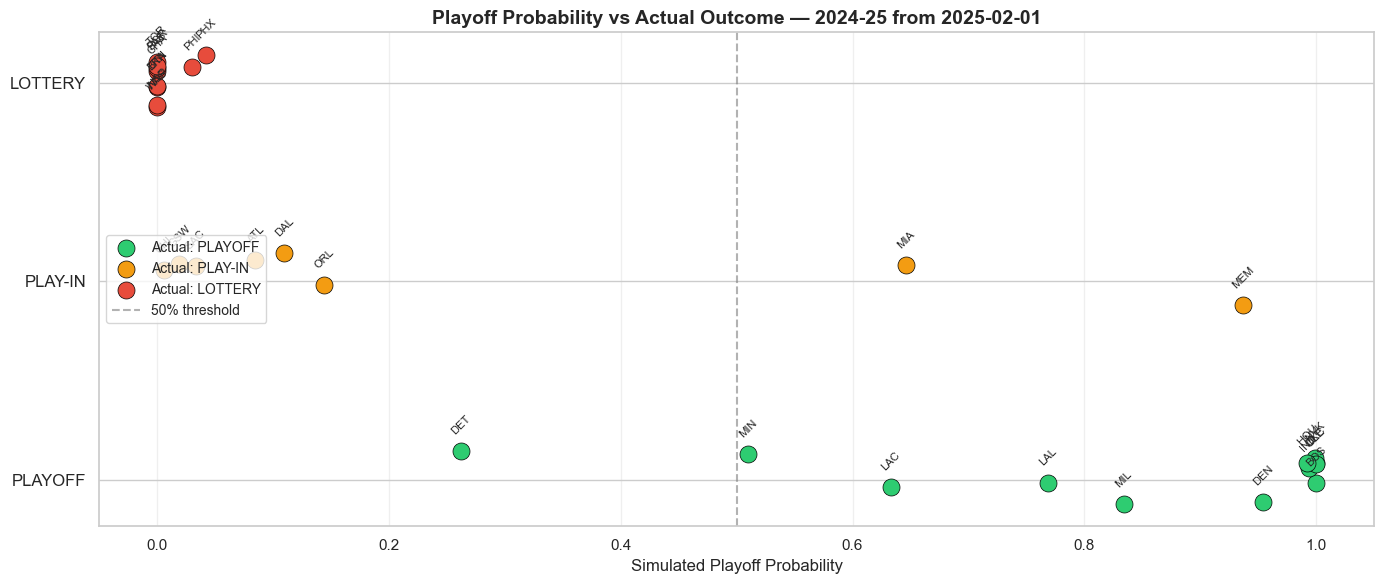

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

status_colors = {'PLAYOFF': '#2ecc71', 'PLAY-IN': '#f39c12', 'LOTTERY': '#e74c3c'}
status_order = ['PLAYOFF', 'PLAY-IN', 'LOTTERY']

for status in status_order:
    c = compare[compare['actual_status'] == status]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(c))
    y_pos = [status_order.index(status) + j for j in jitter]
    ax.scatter(c['playoff_prob'], y_pos, s=150, c=status_colors[status],
               edgecolor='black', lw=0.5, label=f'Actual: {status}', zorder=3)
    for (_, row), yp in zip(c.iterrows(), y_pos):
        ax.annotate(row['team'], (row['playoff_prob'], yp),
                    textcoords='offset points', xytext=(0, 12), fontsize=8,
                    ha='center', rotation=45)

ax.axvline(0.5, color='gray', ls='--', lw=1.5, alpha=0.6, label='50% threshold')
ax.set_yticks(range(3))
ax.set_yticklabels(status_order, fontsize=12)
ax.set_xlabel('Simulated Playoff Probability', fontsize=12)
ax.set_title(f'Playoff Probability vs Actual Outcome — {SEASON} from {CUTOFF}',
             fontsize=14, fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.legend(loc='center left', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

## 5. Win Distributions — Bubble Teams

The 6 most uncertain teams (playoff probability between 5% and 95%). These are the teams where the simulation's uncertainty was highest — and where second-half surprises actually flipped outcomes.

2026-04-17 01:18:26,215 [INFO] As of 2025-02-01 (2024-25): 30 teams, 720 played, 510 remaining


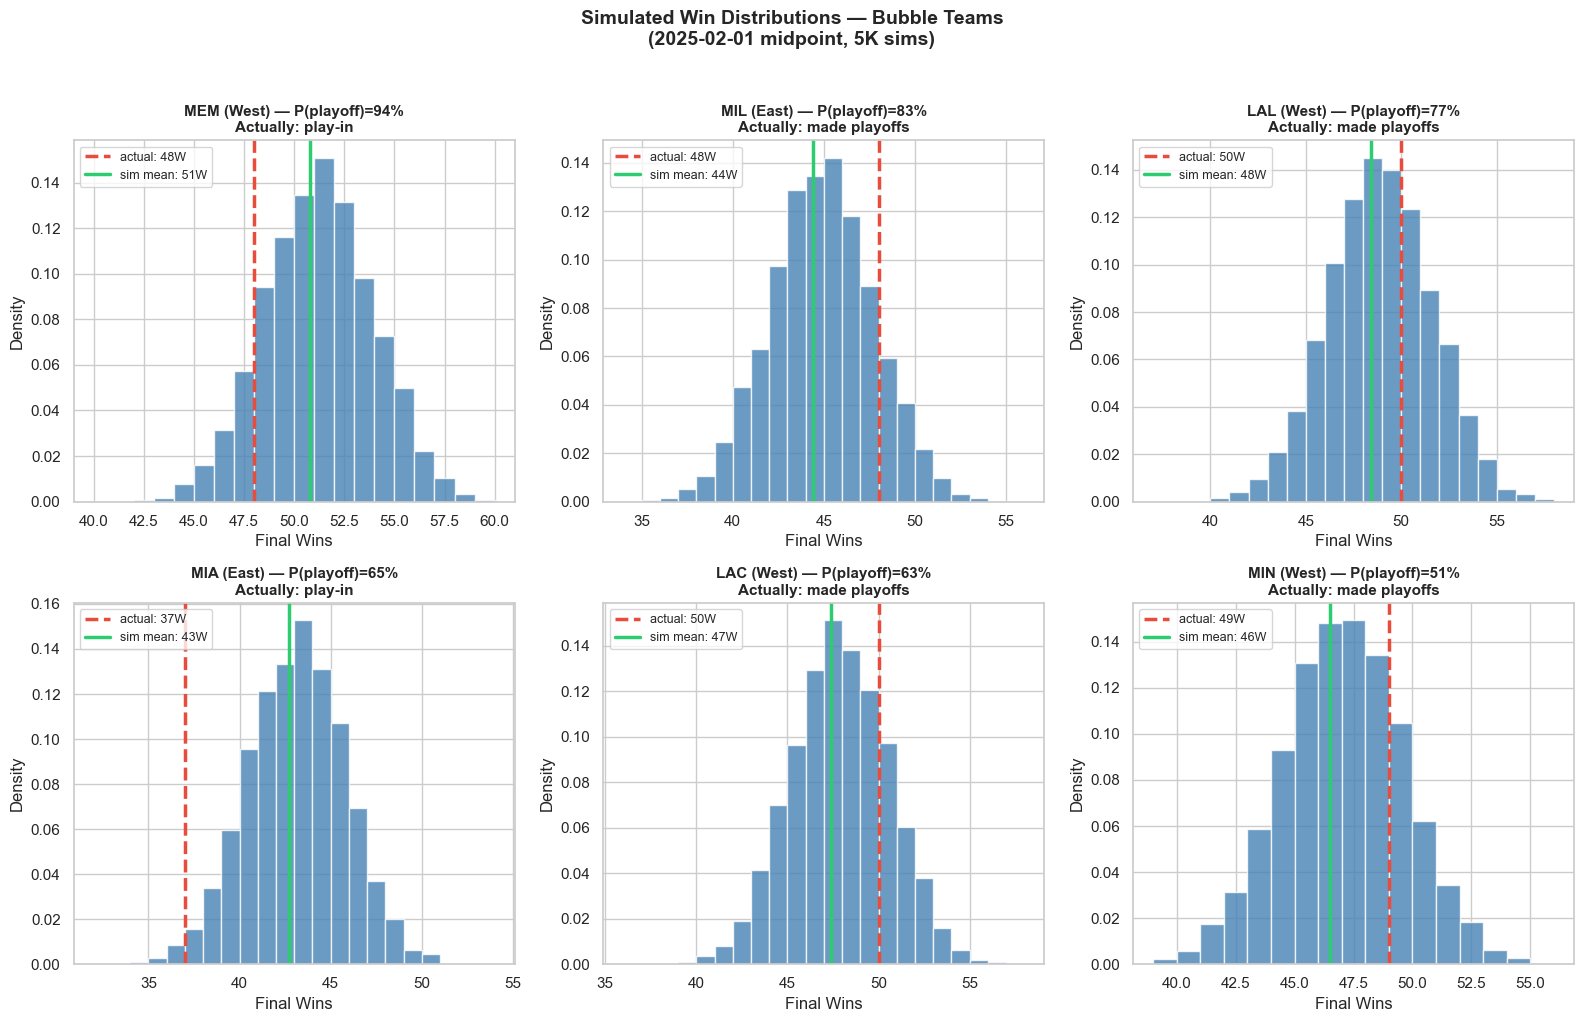

In [6]:
# Re-run a smaller sim to capture per-team win distributions
state = season_state_at(CUTOFF, season=SEASON)
rng = np.random.default_rng(42)

team_wins_raw = {}
for _ in range(5000):
    final = simulate_once(state.standings, state.remaining, state.ratings,
                          state.last_season, state.cutoff_season, rng)
    for _, row in final.iterrows():
        tid = int(row['team_id'])
        team_wins_raw.setdefault(tid, []).append(int(row['wins']))

bubble = compare[(compare['playoff_prob'] > 0.05) & (compare['playoff_prob'] < 0.95)]
bubble = bubble.sort_values('playoff_prob', ascending=False)

n_teams = min(6, len(bubble))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i in range(n_teams):
    ax = axes[i]
    row = bubble.iloc[i]
    tid = int(row['team_id'])
    wins = np.array(team_wins_raw[tid])

    ax.hist(wins, bins=range(int(wins.min()), int(wins.max()) + 2),
            color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(row['actual_wins'], color='#e74c3c', lw=2.5, ls='--',
               label=f"actual: {int(row['actual_wins'])}W")
    ax.axvline(row['wins_mean'], color='#2ecc71', lw=2.5,
               label=f"sim mean: {row['wins_mean']:.0f}W")

    status_emoji = {'PLAYOFF': 'made playoffs', 'PLAY-IN': 'play-in', 'LOTTERY': 'lottery'}
    ax.set_title(f"{row['team']} ({row['conference']}) — P(playoff)={row['playoff_prob']:.0%}\n"
                 f"Actually: {status_emoji[row['actual_status']]}",
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Final Wins')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9, loc='upper left')

# Hide unused subplots
for i in range(n_teams, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Simulated Win Distributions — Bubble Teams\n({CUTOFF} midpoint, 5K sims)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

## 6. Biggest Misses — Detailed Breakdown

The teams the simulator got wrong, with their second-half records showing what changed after the cutoff.

In [9]:
misses = compare[~compare['correct']].copy()
misses['win_delta'] = misses['actual_wins'] - misses['wins_mean']
misses['second_half_wins'] = misses['actual_wins'] - misses['current_wins']
misses['second_half_losses'] = misses['actual_losses'] - misses['current_losses']
misses['second_half'] = misses.apply(
    lambda r: f"{int(r['second_half_wins'])}-{int(r['second_half_losses'])}", axis=1)

display(misses[['team', 'conference', 'current_wins', 'current_losses',
                'second_half', 'wins_mean', 'actual_wins', 'win_delta',
                'playoff_prob', 'sim_status', 'actual_status']].reset_index(drop=True).style.format(
    {'wins_mean': '{:.1f}', 'win_delta': '{:+.1f}', 'playoff_prob': '{:.1%}'}
))

print()
for _, row in misses.iterrows():
    direction = "outperformed" if row['win_delta'] > 0 else "underperformed"
    print(f"{row['team']} ({row['conference']}): {direction} sim by {abs(row['win_delta']):.1f} wins")
    print(f"  Sim predicted: {row['sim_status']} (P={row['playoff_prob']:.0%}), "
          f"Actual: {row['actual_status']}")
    print(f"  At cutoff: {int(row['current_wins'])}-{int(row['current_losses'])}, "
          f"then went {row['second_half']} in second half")
    print()

,team,conference,current_wins,current_losses,second_half,wins_mean,actual_wins,win_delta,playoff_prob,sim_status,actual_status
0,MIA,East,24,23,13-22,42.7,37,-5.7,64.6%,PLAYOFF,PLAY-IN
1,DET,East,24,24,20-14,40.2,44,+3.8,26.2%,PLAY-IN,PLAYOFF
2,PHI,East,19,28,5-30,36.4,24,-12.4,3.0%,PLAY-IN,LOTTERY
3,CHI,East,21,28,18-15,34.7,39,+4.3,0.5%,LOTTERY,PLAY-IN
4,MEM,West,32,16,16-18,50.8,48,-2.8,93.7%,PLAYOFF,PLAY-IN
5,PHX,West,25,23,11-23,41.7,36,-5.7,4.2%,PLAY-IN,LOTTERY



MIA (East): underperformed sim by 5.7 wins
  Sim predicted: PLAYOFF (P=65%), Actual: PLAY-IN
  At cutoff: 24-23, then went 13-22 in second half

DET (East): outperformed sim by 3.8 wins
  Sim predicted: PLAY-IN (P=26%), Actual: PLAYOFF
  At cutoff: 24-24, then went 20-14 in second half

PHI (East): underperformed sim by 12.4 wins
  Sim predicted: PLAY-IN (P=3%), Actual: LOTTERY
  At cutoff: 19-28, then went 5-30 in second half

CHI (East): outperformed sim by 4.3 wins
  Sim predicted: LOTTERY (P=1%), Actual: PLAY-IN
  At cutoff: 21-28, then went 18-15 in second half

MEM (West): underperformed sim by 2.8 wins
  Sim predicted: PLAYOFF (P=94%), Actual: PLAY-IN
  At cutoff: 32-16, then went 16-18 in second half

PHX (West): underperformed sim by 5.7 wins
  Sim predicted: PLAY-IN (P=4%), Actual: LOTTERY
  At cutoff: 25-23, then went 11-23 in second half



## 7. Conference Standings — Sim vs Actual

Side-by-side view per conference. Bars = actual final wins (green if correctly classified, red if missed). Diamond markers with error bars = simulated mean + 90% confidence interval.

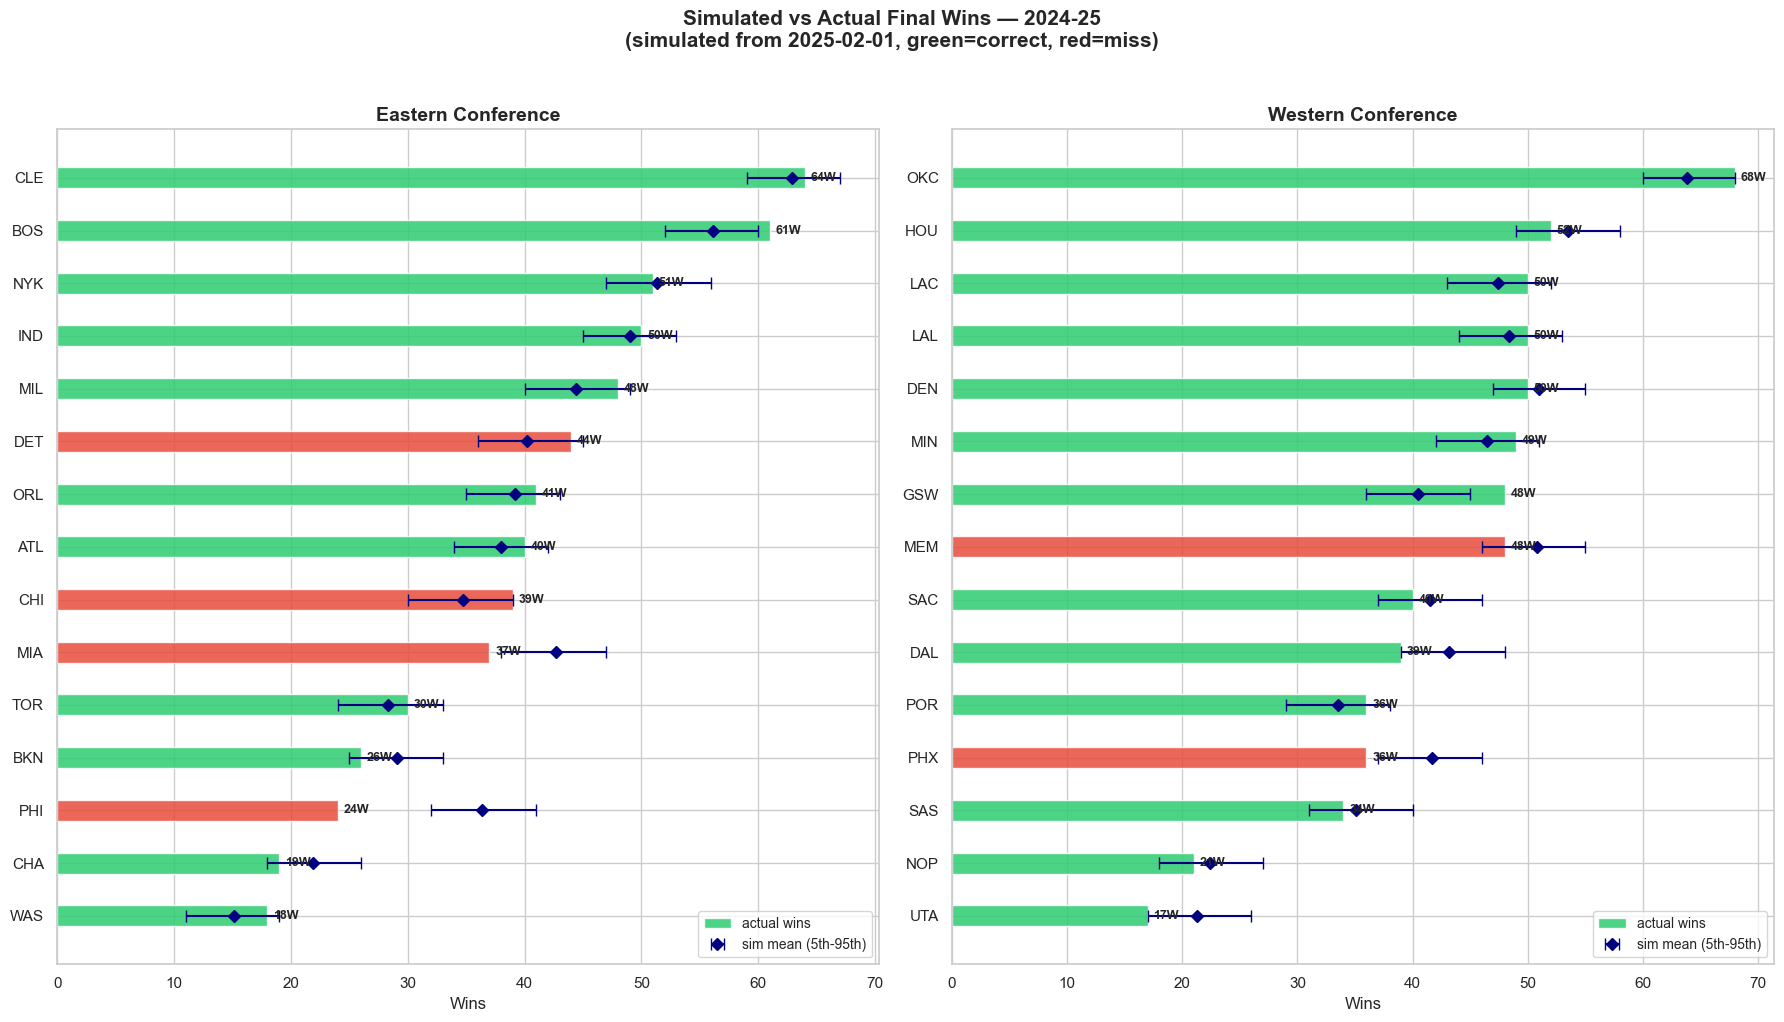

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, conf in zip(axes, ('East', 'West')):
    c = compare[compare['conference'] == conf].sort_values('actual_wins', ascending=True)
    y = np.arange(len(c))

    bar_colors = ['#2ecc71' if corr else '#e74c3c' for corr in c['correct']]
    ax.barh(y, c['actual_wins'], height=0.4, align='edge', color=bar_colors,
            edgecolor='white', alpha=0.85, label='actual wins')

    ax.errorbar(c['wins_mean'], y + 0.2,
                xerr=[c['wins_mean'] - c['wins_p5'], c['wins_p95'] - c['wins_mean']],
                fmt='D', color='navy', markersize=6, capsize=4, lw=1.5,
                label='sim mean (5th-95th)')

    ax.set_yticks(y + 0.2)
    ax.set_yticklabels(c['team'], fontsize=11)
    ax.set_xlabel('Wins', fontsize=12)
    ax.set_title(f'{conf}ern Conference', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')

    for yi, (_, row) in zip(y, c.iterrows()):
        ax.text(row['actual_wins'] + 0.5, yi + 0.2,
                f"{int(row['actual_wins'])}W", va='center', fontsize=9, fontweight='bold')

fig.suptitle(f'Simulated vs Actual Final Wins — {SEASON}\n'
             f'(simulated from {CUTOFF}, green=correct, red=miss)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

## 8. Summary

Key takeaways from the Monte Carlo backtest:

In [11]:
r2 = r2_score(compare['actual_wins'], compare['wins_mean'])
mae = (compare['actual_wins'] - compare['wins_mean']).abs().mean()
n_correct = compare['correct'].sum()
n_miss = (~compare['correct']).sum()

print("=" * 60)
print("Monte Carlo Playoff Simulator — Backtest Summary")
print("=" * 60)
print()
print(f"Season:              {SEASON}")
print(f"Cutoff date:         {CUTOFF}")
print(f"Games per team:      ~{int(compare['current_wins'].mean() + compare['current_losses'].mean())} played, "
      f"~{int(82 - compare['current_wins'].mean() - compare['current_losses'].mean())} remaining")
print(f"Simulations:         {N_SIMS:,}")
print()
print(f"Win prediction R2:   {r2:.3f}")
print(f"Win prediction MAE:  {mae:.1f} wins")
print()
print(f"Classification:      {n_correct}/30 correct ({n_correct/30:.0%})")
print(f"Misses:              {n_miss} teams")
for _, row in compare[~compare['correct']].iterrows():
    print(f"  - {row['team']}: sim={row['sim_status']} ({row['playoff_prob']:.0%}), "
          f"actual={row['actual_status']}")
print()
print("Interpretation:")
print("  - Locks (>99%) and busts (<1%) were all correct")
print("  - All misses were in the 5-95% uncertainty zone")
print("  - The failures are structurally unpredictable:")
print("    mid-season trades, injuries, and motivation shifts")
print("=" * 60)

Monte Carlo Playoff Simulator — Backtest Summary

Season:              2024-25
Cutoff date:         2025-02-01
Games per team:      ~48 played, ~34 remaining
Simulations:         10,000

Win prediction R2:   0.908
Win prediction MAE:  3.2 wins

Classification:      24/30 correct (80%)
Misses:              6 teams
  - MIA: sim=PLAYOFF (65%), actual=PLAY-IN
  - DET: sim=PLAY-IN (26%), actual=PLAYOFF
  - PHI: sim=PLAY-IN (3%), actual=LOTTERY
  - CHI: sim=LOTTERY (1%), actual=PLAY-IN
  - MEM: sim=PLAYOFF (94%), actual=PLAY-IN
  - PHX: sim=PLAY-IN (4%), actual=LOTTERY

Interpretation:
  - Locks (>99%) and busts (<1%) were all correct
  - All misses were in the 5-95% uncertainty zone
  - The failures are structurally unpredictable:
    mid-season trades, injuries, and motivation shifts
